In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

In [2]:
# 1. Загружаем данные
df = pd.read_csv('Mall_Customers.csv')

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о столбцах и типах:")
print(df.info())

print("\nОписательные статистики:")
display(df.describe())

print("\nПроверка пропусков:")
print(df.isnull().sum())

Размер данных: (200, 5)

Первые 5 строк:


,CustomerID,Пол,Возраст,Годовой доход (k$),Оценка расходов (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Информация о столбцах и типах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   CustomerID               200 non-null    int64 
 1   Пол                      200 non-null    object
 2   Возраст                  200 non-null    int64 
 3   Годовой доход (k$)       200 non-null    int64 
 4   Оценка расходов (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Описательные статистики:


,CustomerID,Возраст,Годовой доход (k$),Оценка расходов (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Проверка пропусков:
CustomerID                 0
Пол                        0
Возраст                    0
Годовой доход (k$)         0
Оценка расходов (1-100)    0
dtype: int64


In [3]:
# Выбираем признаки для кластеризации
features = ['Возраст', 'Годовой доход (k$)', 'Оценка расходов (1-100)']
X = df[features]

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Превращаем обратно в DataFrame для удобства
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Масштабированные данные (первые 5 строк):")
display(X_scaled_df.head())

Масштабированные данные (первые 5 строк):


,Возраст,Годовой доход (k$),Оценка расходов (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [4]:
# Задаём число кластеров (позже подберём оптимальное, пока возьмём 5)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Распределение по кластерам:")
print(df['Cluster'].value_counts().sort_index())

display(df.head())

Распределение по кластерам:
0    23
1    45
2    33
3    39
4    39
5    21
Name: Cluster, dtype: int64


,CustomerID,Пол,Возраст,Годовой доход (k$),Оценка расходов (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,5
3,4,Female,23,16,77,0
4,5,Female,31,17,40,5


Изначально взяла 5, но после оценки силуэта стало понятно, что лучше взять 6, а не 5. Потому что при 6 кластерах мы видими максимальный силуэтный коэффициент. Это значит, что при 6 кластерах объекты лучше всего отделены друг от друга и компактны внутри групп.

Результаты для разных k:


,k,Inertia,Silhouette
0,2,389.3862,0.3355
1,3,295.2122,0.3578
2,4,205.2251,0.4040
3,5,168.2476,0.4166
4,6,133.8684,0.4284
5,7,120.4328,0.4112
6,8,103.8153,0.4084
7,9,92.3495,0.4201
8,10,82.8853,0.4226


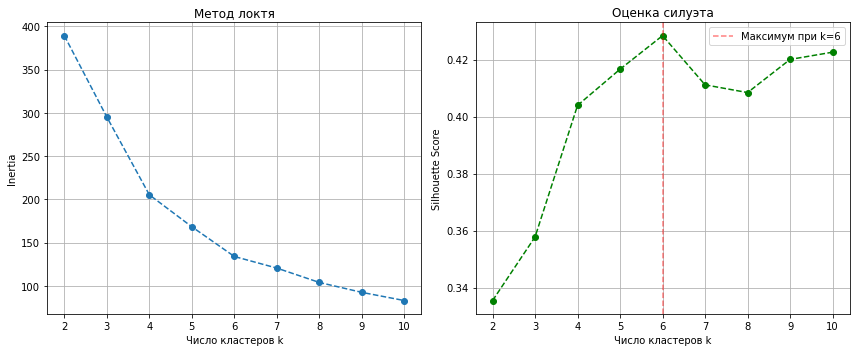


Максимальный силуэтный коэффициент достигается при k = 6


In [5]:
# Метод локтя + силуэт 
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Вывод результатов в таблицу
results = pd.DataFrame({
    'k': K_range,
    'Inertia': inertias,
    'Silhouette': silhouettes
})
print("Результаты для разных k:")
display(results.round(4))

# Графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linestyle='--')
plt.xlabel('Число кластеров k')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', linestyle='--', color='green')
plt.xlabel('Число кластеров k')
plt.ylabel('Silhouette Score')
plt.title('Оценка силуэта')
plt.grid(True)

# Отмечаем максимум силуэта
max_sil_k = K_range[np.argmax(silhouettes)]
plt.axvline(x=max_sil_k, color='red', linestyle='--', alpha=0.5, label=f'Максимум при k={max_sil_k}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nМаксимальный силуэтный коэффициент достигается при k = {max_sil_k}")

- Метод локтя: график инерции показывает, что после k=6 снижение замедляется, но чёткого «локтя» нет.

- Силуэтный коэффициент: достигает максимума при k=6. Это означает, что при 6 кластерах объекты лучше всего отделены друг от друга и компактны внутри групп.

#Вывод:
выбираем k=6 как оптимальное число кластеров, поскольку оно даёт наилучшую разделимость согласно силуэту.

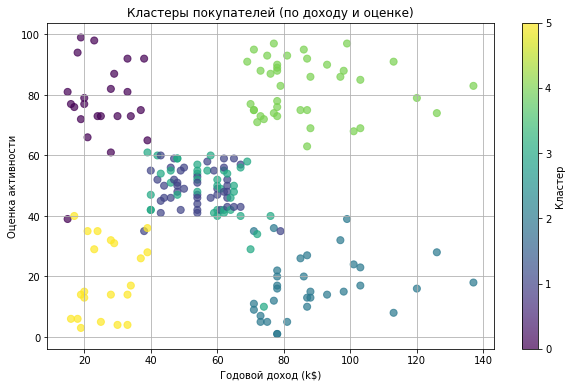

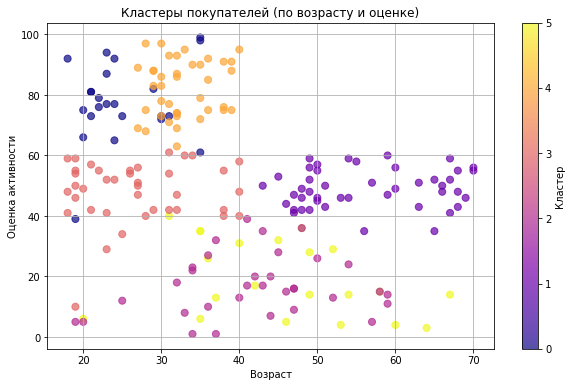

In [6]:
# Визуализация по двум главным признакам: доход и оценка
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Годовой доход (k$)'], 
                      df['Оценка расходов (1-100)'],
                      c=df['Cluster'], 
                      cmap='viridis', 
                      s=50, 
                      alpha=0.7)

plt.colorbar(scatter, label='Кластер')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Оценка активности')
plt.title('Кластеры покупателей (по доходу и оценке)')
plt.grid(True)
plt.show()

# Дополнительно — по возрасту и оценке
plt.figure(figsize=(10, 6))
scatter2 = plt.scatter(df['Возраст'], 
                       df['Оценка расходов (1-100)'],
                       c=df['Cluster'], 
                       cmap='plasma', 
                       s=50, 
                       alpha=0.7)

plt.colorbar(scatter2, label='Кластер')
plt.xlabel('Возраст')
plt.ylabel('Оценка активности')
plt.title('Кластеры покупателей (по возрасту и оценке)')
plt.grid(True)
plt.show()

In [7]:
# Средние значения признаков по кластерам
cluster_means = df.groupby('Cluster')[['Возраст', 'Годовой доход (k$)', 'Оценка расходов (1-100)']].mean()
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_means['Count'] = cluster_counts

print("Средние характеристики кластеров:")
display(cluster_means.round(2))

Средние характеристики кластеров:


,Возраст,Годовой доход (k$),Оценка расходов (1-100),Count
Cluster,,,,
0,25.00,25.26,77.61,23
1,56.33,54.27,49.07,45
2,41.94,88.94,16.97,33
3,26.79,57.10,48.13,39
4,32.69,86.54,82.13,39
5,45.52,26.29,19.38,21


На основе средних значений я даю кластерам такие названия:

- Кластер 0 (Молодые с низким доходом и высокой активностью) — возраст ~25, доход ~25, оценка ~77. (23 чел (~11% аудитории)). Самый молодой сегмент с минимальным доходом, но высокой покупательской активностью. Это студенты или молодые специалисты, которые активно тратят, несмотря на ограниченный бюджет. Данной аудитории нужно предлагать товары эконом-сегмента, скидки, акции, рассрочку и программы лояльности. Важно удержать их через специальные предложения для молодёжи.

- Кластер 1 (Пожилые со средними показателями) — возраст ~56, доход ~54, оценка ~49. 45 человек (~22% аудитории) — самый многочисленный сегмент. Самая старшая возрастная группа со средним доходом и средней активностью. Консервативные покупатели, которые тратят умеренно. Стоит предлагать товары для дома, здоровья и повседневного спроса. Упрощённый интерфейс, скидки для пенсионеров, товары с гарантией качества.

- Кластер 2 (Зрелые с высоким доходом, но низкой активностью) — возраст ~41, доход ~88, оценка ~16. 33 человека (~16% аудитории). Взрослые люди с очень высоким доходом, но крайне низкой покупательской активностью. Возможно, они не находят интересных предложений или предпочитают другие каналы покупок.Необходимы персонализированные рекомендации премиум-товаров, эксклюзивные предложения, вовлечение через индивидуальный подход. Важно выяснить причины низкой активности и стимулировать пробные покупки.

- Кластер 3 (Молодые со средним доходом и средней активностью) — возраст ~26, доход ~57, оценка ~48. 39 человек (~19% аудитории). Молодые люди со средним доходом и умеренной активностью. Потенциально растущий сегмент с возможностью увеличения среднего чека. Кросс-продажи, апсейлинг, предложение товаров среднего ценового сегмента. Можно тестировать новые продукты, так как сегмент активен и открыт к новому.

- Кластер 4 ("Золотые клиенты" (высокий доход + высокая активность)) — возраст ~32, доход ~86, оценка ~82. 39 человек (~19% аудитории). Самый ценный сегмент! Молодые люди с высоким доходом и максимальной покупательской активностью. Это ядро лояльной и платёжеспособной аудитории. Премиум-предложения, эксклюзивные товары, персональный менеджер, программы повышения лояльности, ранний доступ к новинкам. Удерживать любой ценой.

- Кластер 5 (Пожилые с низким доходом и низкой активностью) — возраст ~45, доход ~26, оценка ~19. 21 человек (~10% аудитории) - самый малочисленный сегмент. Взрослые люди с низким доходом и минимальной активностью. Возможно, не привыкли к онлайн-покупкам или имеют ограниченные финансовые возможности. Стоит предлагать простые и понятные предложения, товары первой необходимости, скидки для постоянных клиентов. Можно использовать email-рассылки с выгодными предложениями.

1. Чувствительность к выбору числа кластеров (k)

Мы подбирали k с помощью метода локтя и силуэтного коэффициента. Однако:

Метод локтя субъективен — разные аналитики могут по-разному сегментировать данные, выделяя различные группы.

Силуэт показал максимум при k=6, но при k=5 группы были более интерпретируемы для бизнеса (меньше сегментов - проще управление) .

Вывод: Не существует единственно правильного k — выбор зависит от задачи и интерпретируемости.

2. Критическая зависимость от масштабирования признаков

Без масштабирования алгоритм кластеризации будет опираться только на признаки с наибольшими числовыми значениями, например, доход и активность намного больше возраста. 

Если не использовать StandardScaler, расстояние между объектами практически полностью определяется доходом, а возраст и активность перестают влиять на результат. Это приводит к некорректным сегментам, где, например, все люди с доходом выше 100 тыс. попадают в один кластер независимо от возраста и поведения.
Роэтому он чувствителен к выбросам.

3. Предположение о сферической форме кластеров

k-means предполагает, что кластеры имеют сферическую форму и примерно одинаковый размер. На реальных данных это редко выполняется. В нашем датасете кластеры могут быть вытянутыми, перекрывающимися или произвольной формы.

Например, кластер 1 (средний доход, средняя активность) и кластер 3 (средний доход, средняя активность) имеют похожий доход и активность — k-means разделил их, но граница может быть нечёткой.

4. Трудность интерпретации кластеров с большим числом признаков. В моем случае тут 3 признака, с ними куда проще работать, чем если бы их было больше.